In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from sklearn.datasets import fetch_openml

# Load Heart Disease dataset
heart = fetch_openml(name="heart-disease", version=1, as_frame=True)

df = heart.frame

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (303, 14)


In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB


In [7]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


target
1.0    165
0.0    138
Name: count, dtype: int64


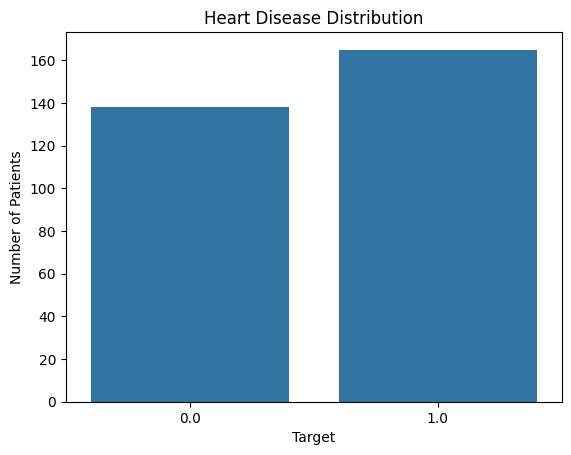

In [9]:
print(df["target"].value_counts())

sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.show()

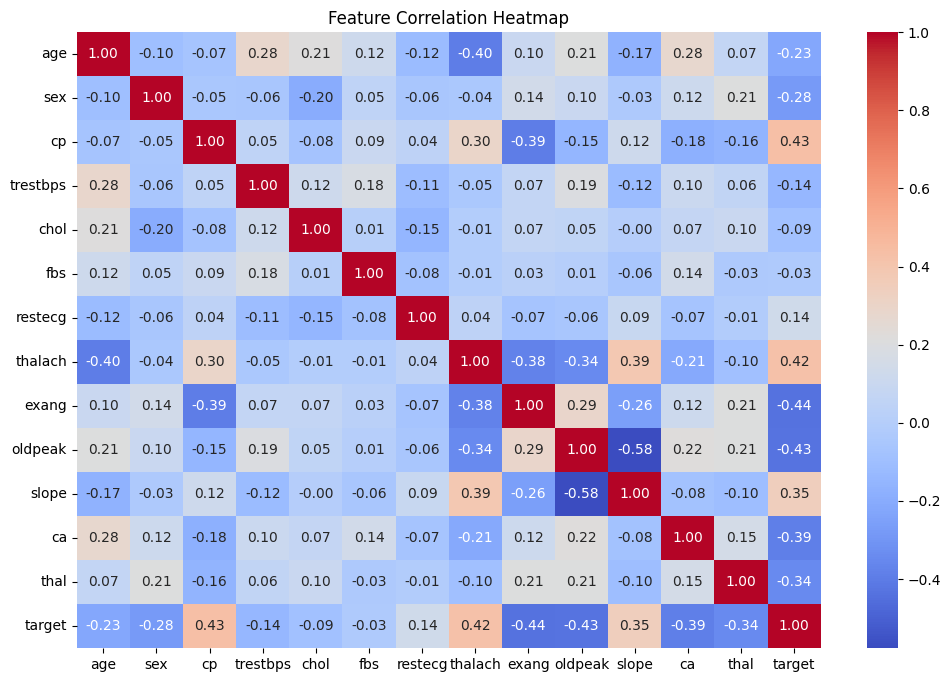

In [10]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
# Separate input features and target variable

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [16]:
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (242, 13)
Scaled testing data shape: (61, 13)


In [17]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

In [18]:
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions completed!")
print(y_pred_lr)

Predictions completed!
[0. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1.]


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1 Score :", round(f1_lr, 4))
print("ROC-AUC  :", round(roc_auc_lr, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.8033
Precision: 0.7692
Recall   : 0.9091
F1 Score : 0.8333
ROC-AUC  : 0.869


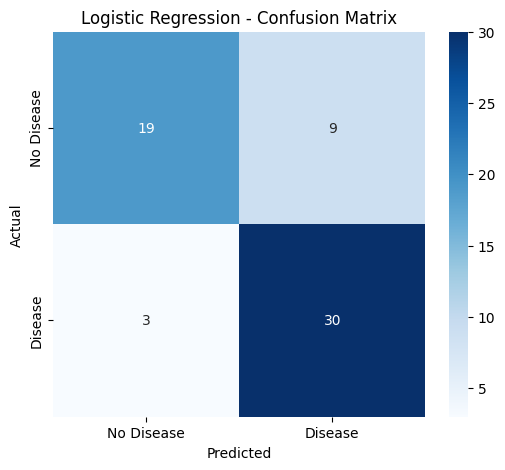

In [21]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No Disease", "Disease"]
))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



In [23]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

print("SVM model created!")

SVM model created!


In [24]:
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [25]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM predictions completed!")

SVM predictions completed!


In [26]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("SVM Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1 Score :", round(f1_svm, 4))
print("ROC-AUC  :", round(roc_auc_svm, 4))

SVM Results
--------------------------------
Accuracy : 0.8197
Precision: 0.775
Recall   : 0.9394
F1 Score : 0.8493
ROC-AUC  : 0.8831


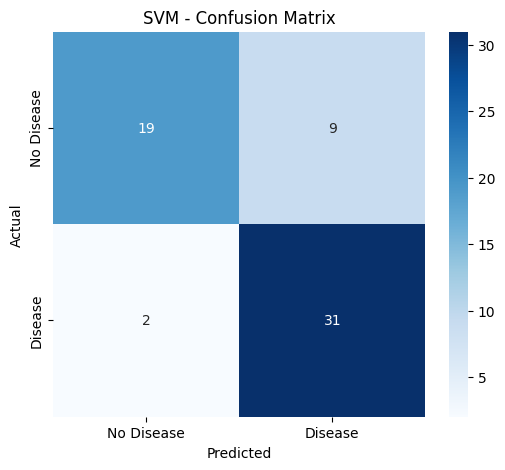

In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
print("SVM Classification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["No Disease", "Disease"]
))

SVM Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.68      0.78        28
     Disease       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created!")

Random Forest model created!


In [30]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [31]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [32]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Results
--------------------------------
Accuracy : 0.8361
Precision: 0.7805
Recall   : 0.9697
F1 Score : 0.8649
ROC-AUC  : 0.9161


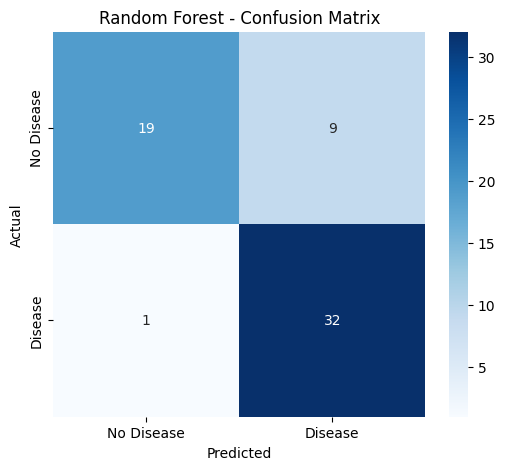

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Disease", "Disease"]
))

Random Forest Classification Report:
              precision    recall  f1-score   support

  No Disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



In [35]:
!pip install -q xgboost

In [36]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost model created!")

XGBoost model created!


In [37]:
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [38]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions completed!")

XGBoost predictions completed!


In [39]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))
print("ROC-AUC  :", round(roc_auc_xgb, 4))

XGBoost Results
--------------------------------
Accuracy : 0.7869
Precision: 0.7632
Recall   : 0.8788
F1 Score : 0.8169
ROC-AUC  : 0.8561


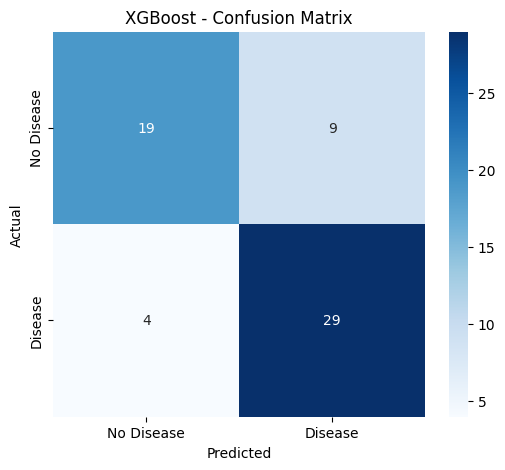

In [40]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
print("XGBoost Classification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Disease", "Disease"]
))

XGBoost Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.68      0.75        28
     Disease       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



In [42]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_svm,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision_lr,
        precision_svm,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall_lr,
        recall_svm,
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1_lr,
        f1_svm,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_svm,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803279,0.769231,0.909091,0.833333,0.869048
1,SVM,0.819672,0.775000,0.939394,0.849315,0.883117
2,Random Forest,0.836066,0.780488,0.969697,0.864865,0.916126
3,XGBoost,0.786885,0.763158,0.878788,0.816901,0.856061


In [43]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8033,0.7692,0.9091,0.8333,0.8690
1,SVM,0.8197,0.7750,0.9394,0.8493,0.8831
2,Random Forest,0.8361,0.7805,0.9697,0.8649,0.9161
3,XGBoost,0.7869,0.7632,0.8788,0.8169,0.8561


In [44]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_f1 = results["F1 Score"].max()

print("Best Model:", best_model_name)
print("Best F1 Score:", round(best_f1, 4))

Best Model: Random Forest
Best F1 Score: 0.8649


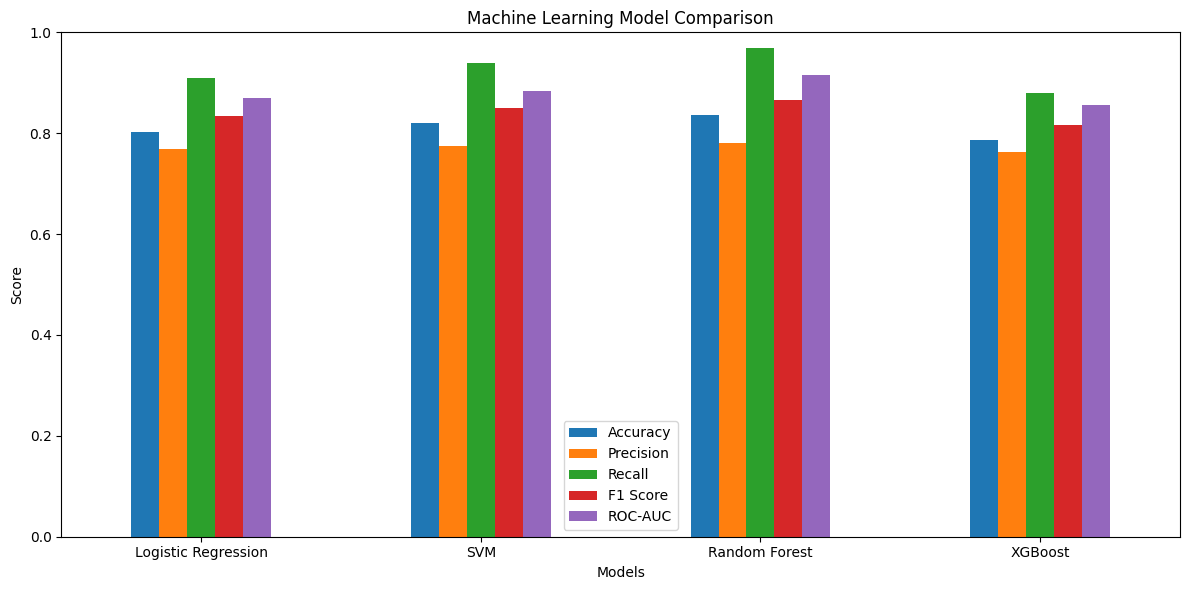

In [45]:
results_plot = results.set_index("Model")

results_plot[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
results.round(4).to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [47]:
best_model_name = results.loc[results["F1 Score"].idxmax(), "Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [48]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    use_scaled = True

elif best_model_name == "SVM":
    best_model = svm_model
    use_scaled = True

elif best_model_name == "Random Forest":
    best_model = rf_model
    use_scaled = False

else:
    best_model = xgb_model
    use_scaled = False

print("Selected:", best_model_name)

Selected: Random Forest


In [49]:
new_patient = pd.DataFrame({
    "age": [55],
    "sex": [1],
    "cp": [1],
    "trestbps": [140],
    "chol": [250],
    "fbs": [0],
    "restecg": [1],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [1.0],
    "slope": [2],
    "ca": [0],
    "thal": [2]
})

print(new_patient)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   55    1   1       140   250    0        1      150      0      1.0      2   

   ca  thal  
0   0     2  


In [52]:
if use_scaled:
    patient_input = scaler.transform(new_patient)
else:
    patient_input = new_patient

print("Patient data prepared successfully!")

Patient data prepared successfully!


In [53]:
prediction = best_model.predict(patient_input)[0]

if prediction == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease Detected")

Prediction: Heart Disease Detected


In [54]:
probability = best_model.predict_proba(patient_input)[0]

print("Probability of No Heart Disease:", round(probability[0] * 100, 2), "%")
print("Probability of Heart Disease:", round(probability[1] * 100, 2), "%")

Probability of No Heart Disease: 14.0 %
Probability of Heart Disease: 86.0 %


In [55]:
!pip install -q joblib

In [56]:
import joblib

joblib.dump(best_model, "best_heart_disease_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [57]:
joblib.dump(scaler, "heart_disease_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [58]:
results.round(4).to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved!")

Model comparison results saved!


In [59]:
import os

print("Files created:")

for file in [
    "best_heart_disease_model.pkl",
    "heart_disease_scaler.pkl",
    "model_comparison_results.csv"
]:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

Files created:
✓ best_heart_disease_model.pkl
✓ heart_disease_scaler.pkl
✓ model_comparison_results.csv


In [60]:
loaded_model = joblib.load("best_heart_disease_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [61]:
loaded_prediction = loaded_model.predict(patient_input)[0]

if loaded_prediction == 1:
    print("Saved Model Prediction: Heart Disease Detected")
else:
    print("Saved Model Prediction: No Heart Disease Detected")

Saved Model Prediction: Heart Disease Detected
